In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import math
import seaborn as sns
from sklearn import preprocessing,metrics
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LogisticRegressionCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [3]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [6]:
print("Initial shape:", df.shape)
print("Duplicates in dataset:", df.duplicated().sum())

Initial shape: (100000, 9)
Duplicates in dataset: 3854


In [7]:
df.drop_duplicates(inplace=True)

print("New shape:", df.shape)
print("Duplicates in dataset:", df.duplicated().sum())

New shape: (96146, 9)
Duplicates in dataset: 0


Text(0.5, 1.0, 'Histogram of Age')

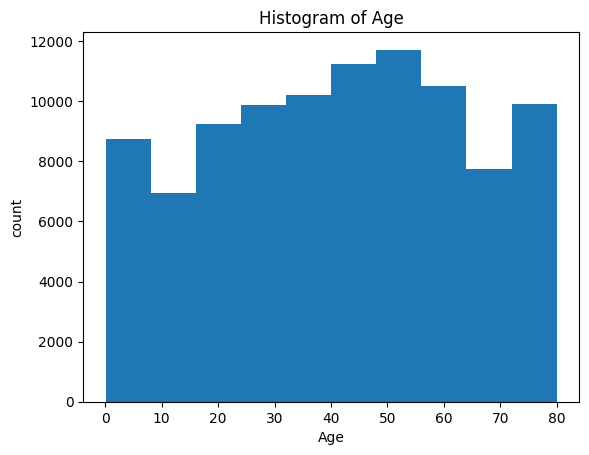

In [8]:
# just looking is histogram of age
plt.hist(df['age'],bins=10);

plt.xlabel('Age')
plt.ylabel('count')

plt.title('Histogram of Age')

<Axes: xlabel='diabetes', ylabel='count'>

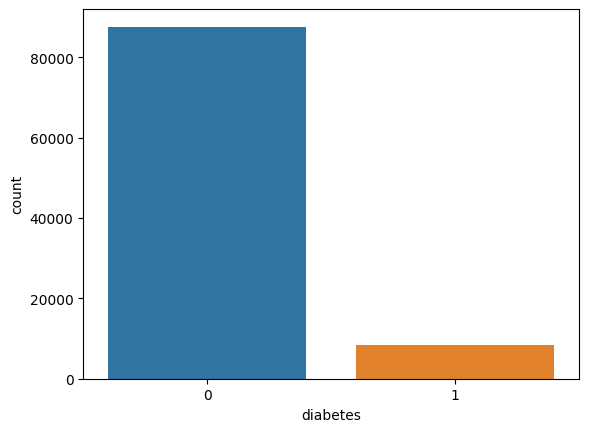

In [9]:
# Count of target Variable
sns.countplot(x=df['diabetes'])

<Axes: xlabel='gender', ylabel='count'>

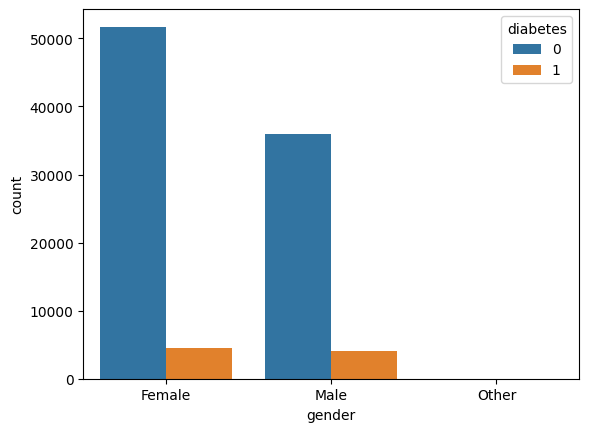

In [10]:
sns.countplot(x=df['gender'],hue=df['diabetes'])

In [11]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


In [13]:
# Create the list of continuous features for further use in prepare charts
continuous_features = list(set(['age','bmi','HbA1c_level','blood_glucose_level']))
continuous_features.sort()
continuous_features

['HbA1c_level', 'age', 'blood_glucose_level', 'bmi']

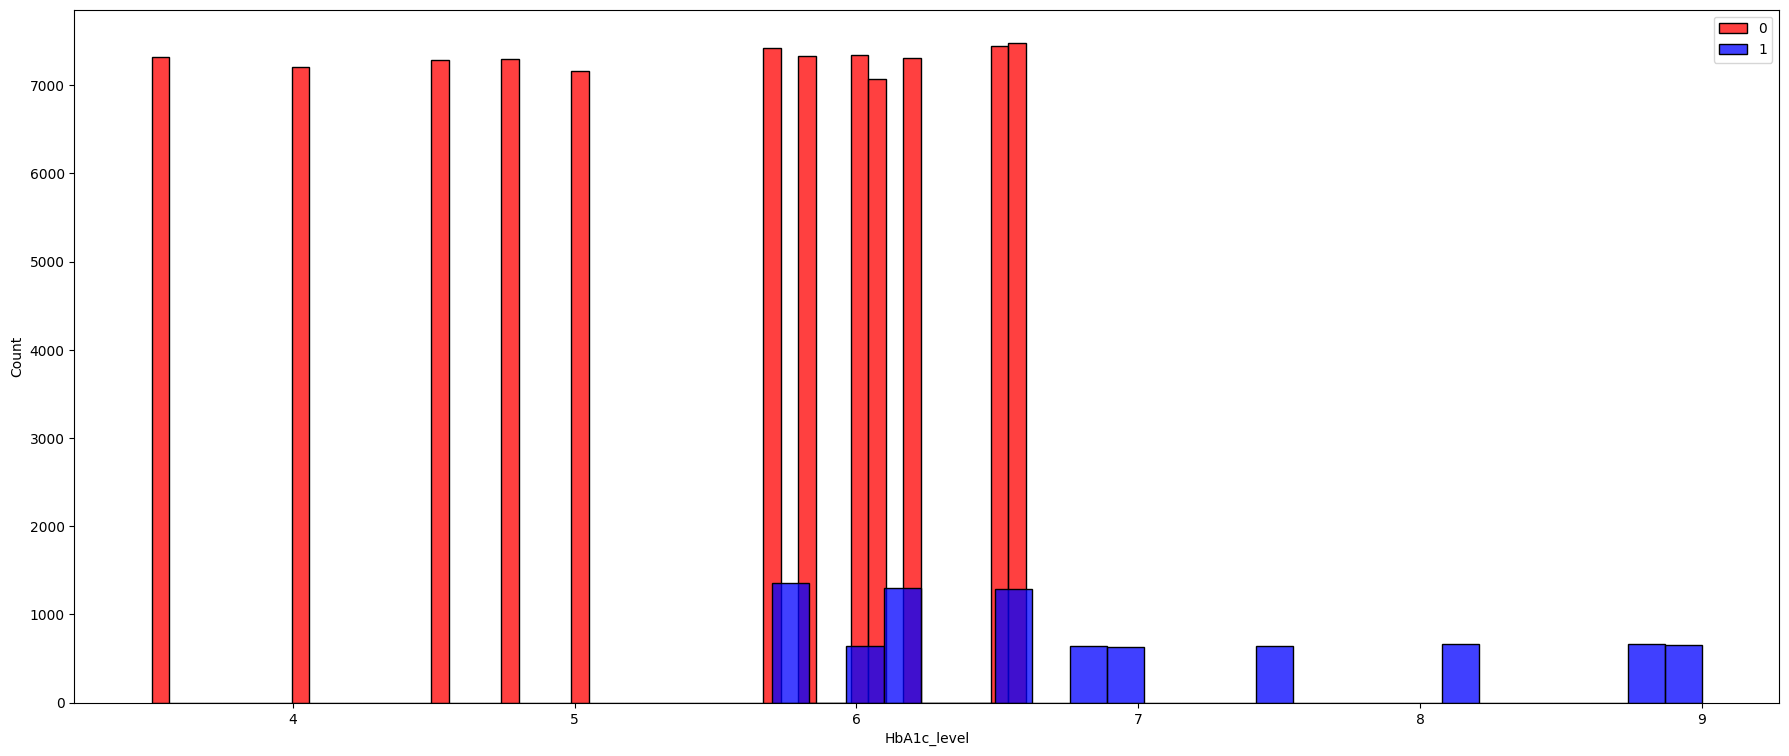

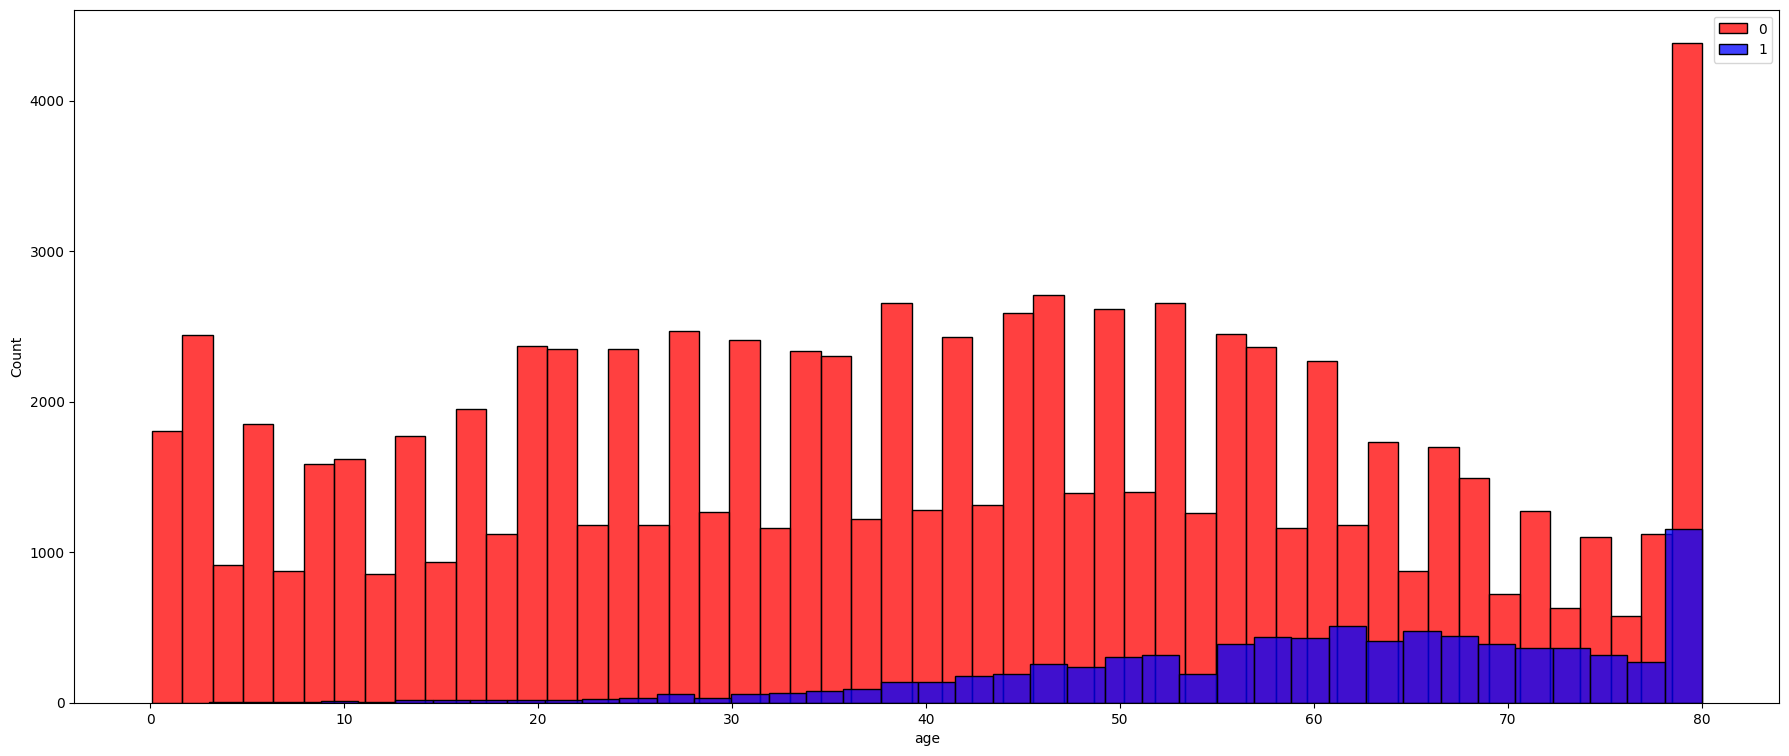

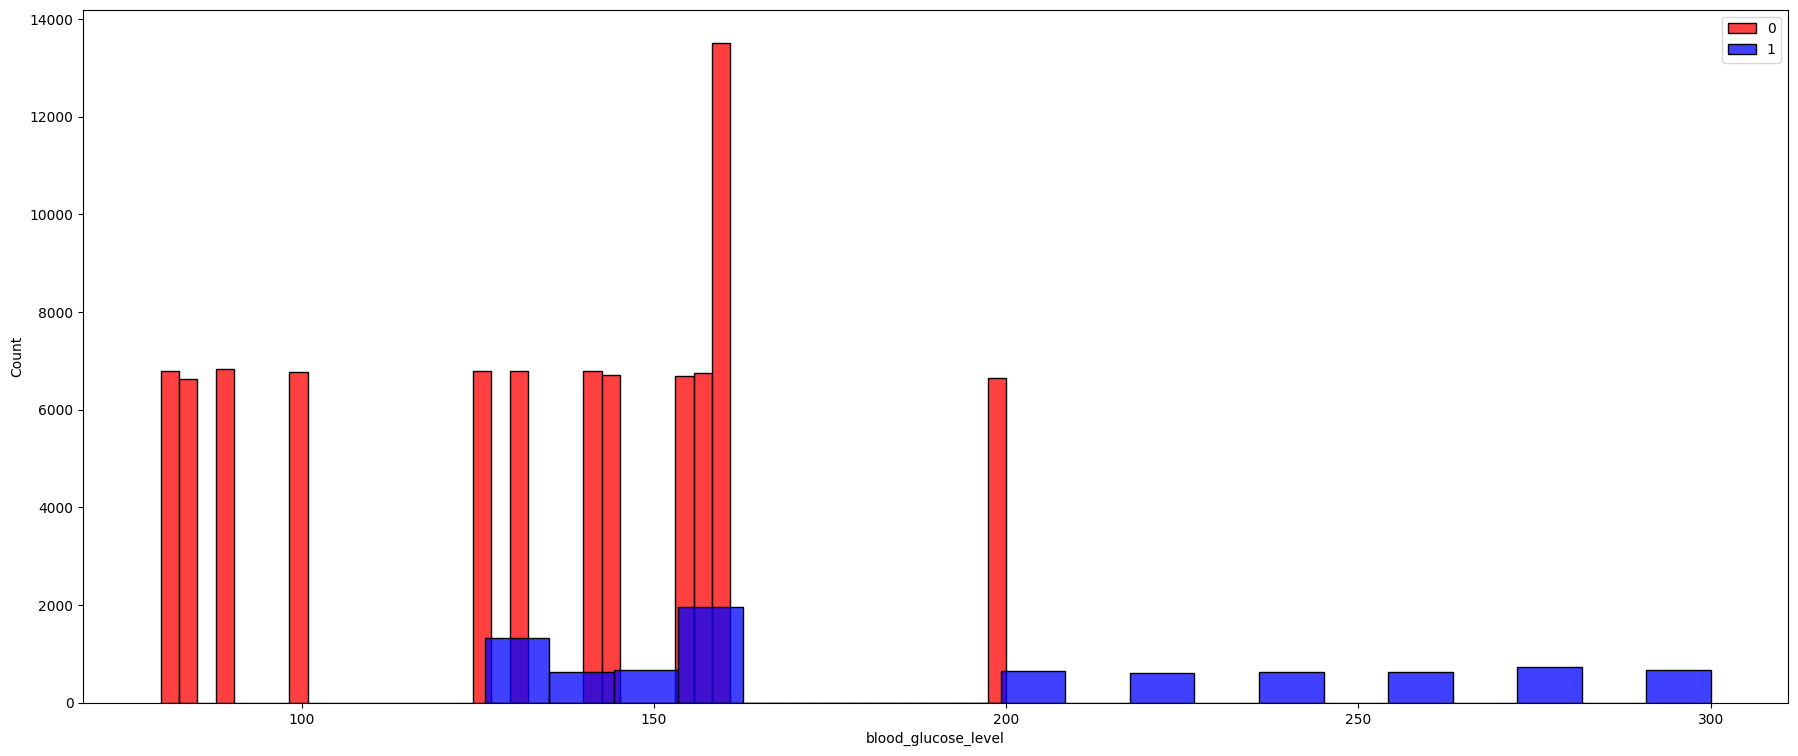

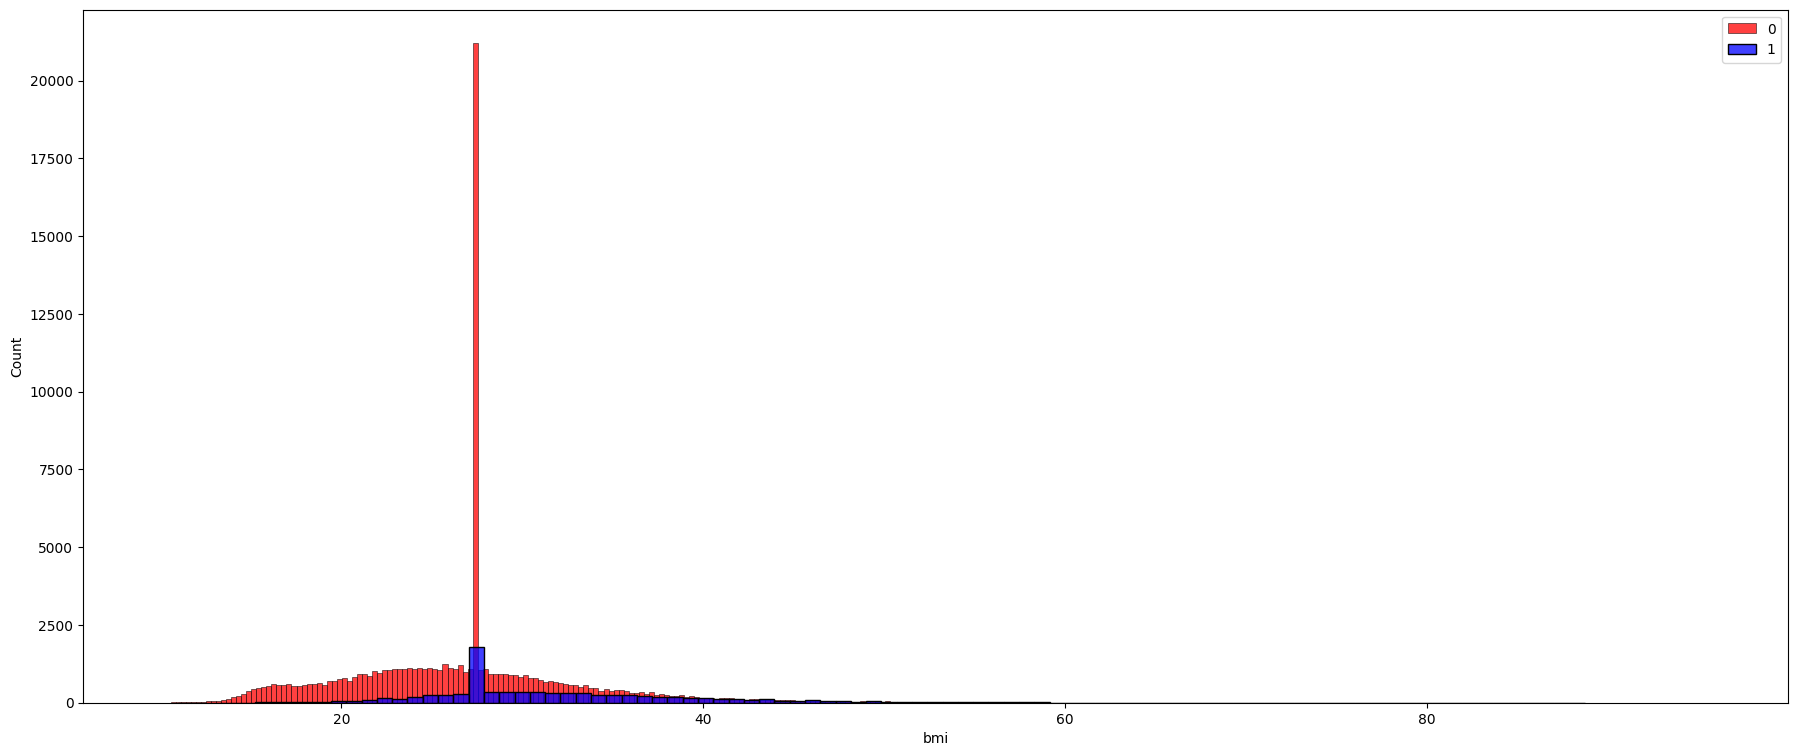

In [14]:
# Histograms for continuous features as per target
for feature in continuous_features:
    fig,axs = plt.subplots(figsize=(22,9))
    sns.histplot(df[df['diabetes']==0][feature],color = 'red')
    sns.histplot(df[df['diabetes']==1][feature],color = 'blue')

    plt.legend([0,1],loc='upper right')
    plt.show()

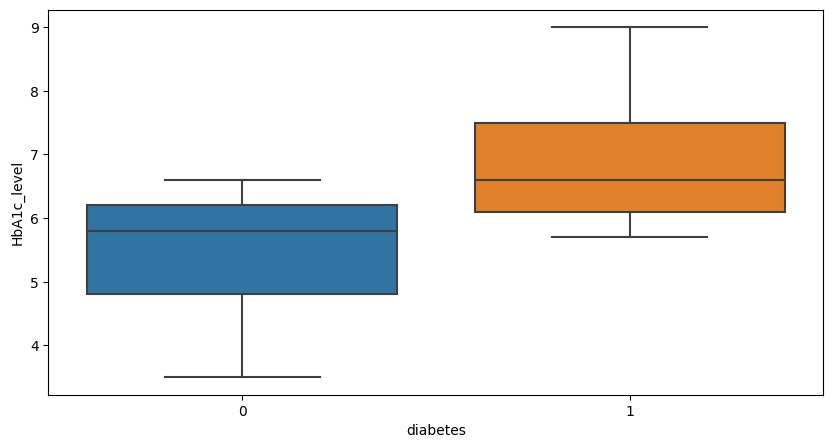

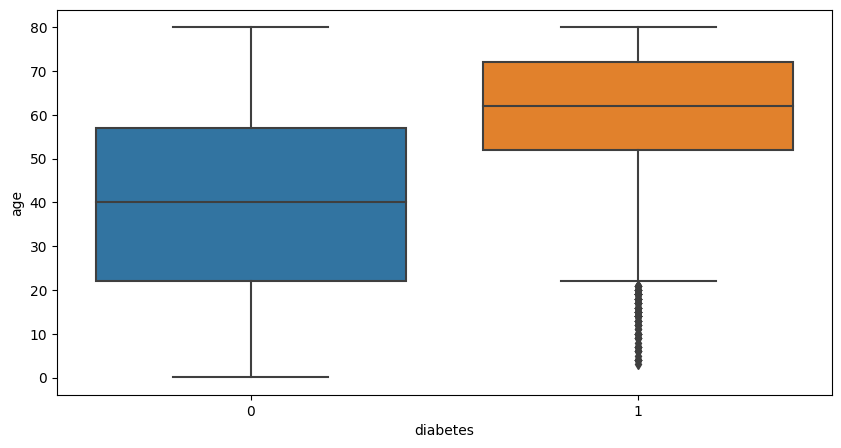

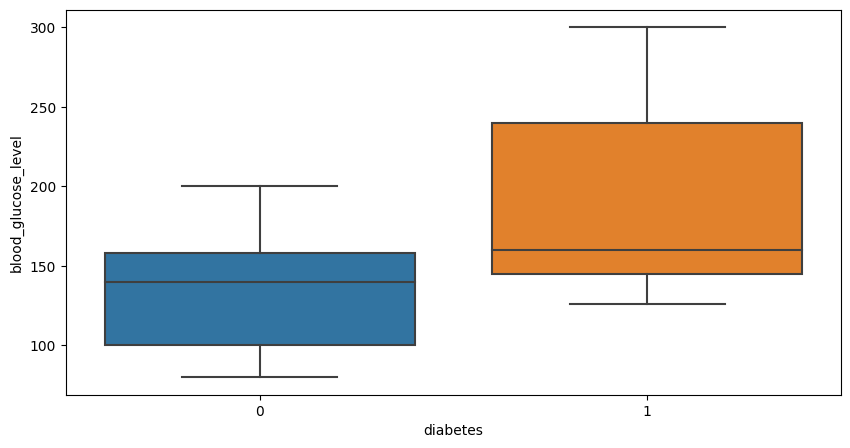

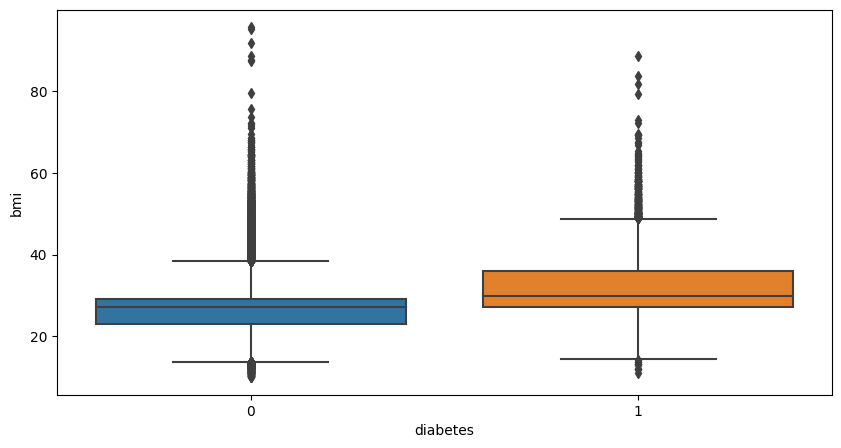

In [15]:
# Boxplot of continuous features
for i in range(len(continuous_features)):
    feature = continuous_features[i]
    plt.figure(figsize = (10, 5))
    sns.boxplot(x='diabetes',y=continuous_features[i],data=df);

In [16]:
# Now as per box plot we see that for some features have quiet a bit variation in mean for diabetes of 0 and 1
# But to compare the means of both stage we need perform statistical test.

# Here by we have performed T-test to compare the mean
import scipy.stats as stats
for feature in continuous_features:
    print('---------------------------------')
    print('T-Test for::',feature)

    statt,p=stats.ttest_ind(df[feature][df['diabetes'] == 0],
                    df[feature][df['diabetes'] == 1])

    if p<.05:
        result="Mean value of for both target Condition is different"
    else:
        result="Mean value of for both target Condition is same"
    print('--> P-value is',p,"\n-->",result,"\n")


---------------------------------
T-Test for:: HbA1c_level
--> P-value is 0.0 
--> Mean value of for both target Condition is different 

---------------------------------
T-Test for:: age
--> P-value is 0.0 
--> Mean value of for both target Condition is different 

---------------------------------
T-Test for:: blood_glucose_level
--> P-value is 0.0 
--> Mean value of for both target Condition is different 

---------------------------------
T-Test for:: bmi
--> P-value is 0.0 
--> Mean value of for both target Condition is different 



<ipython-input-17-1251713e6b64>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot = True);


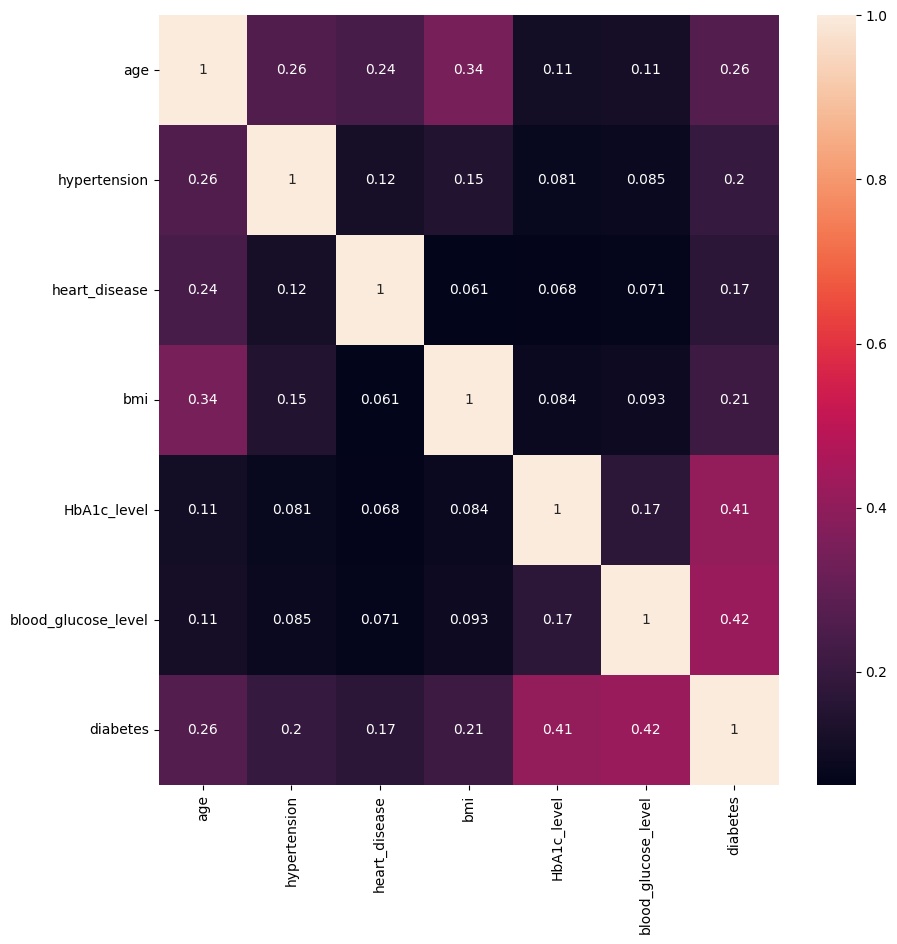

In [17]:
# Correlation of features
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot = True);

In [18]:
# Create the list of categorical features for further use in prepare charts

categorical_features = list(set(df.columns) -set(continuous_features)-set(['diabetes']))
categorical_features.sort()
categorical_features

['gender', 'heart_disease', 'hypertension', 'smoking_history']

In [19]:
#getting the list of unique values and number of unique values of all categorical columns
for col in categorical_features:
    a= df[col].nunique()
    b= df[col].unique()
    print(col)
    print(a)
    print(b)

gender
3
['Female' 'Male' 'Other']
heart_disease
2
[1 0]
hypertension
2
[0 1]
smoking_history
6
['never' 'No Info' 'current' 'former' 'ever' 'not current']


In [20]:
df["smoking_history"] = df["smoking_history"].replace("ever", "never")
df["smoking_history"] = df["smoking_history"].replace("not current", "former")

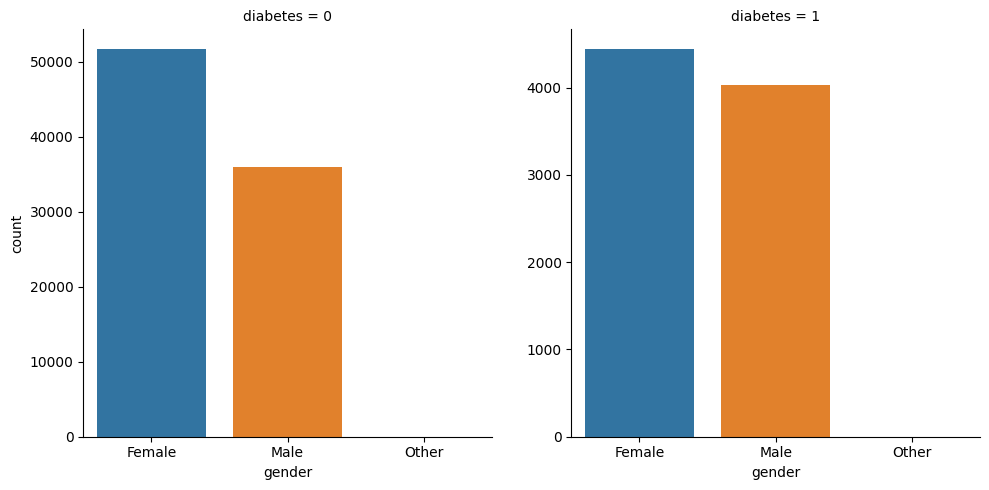

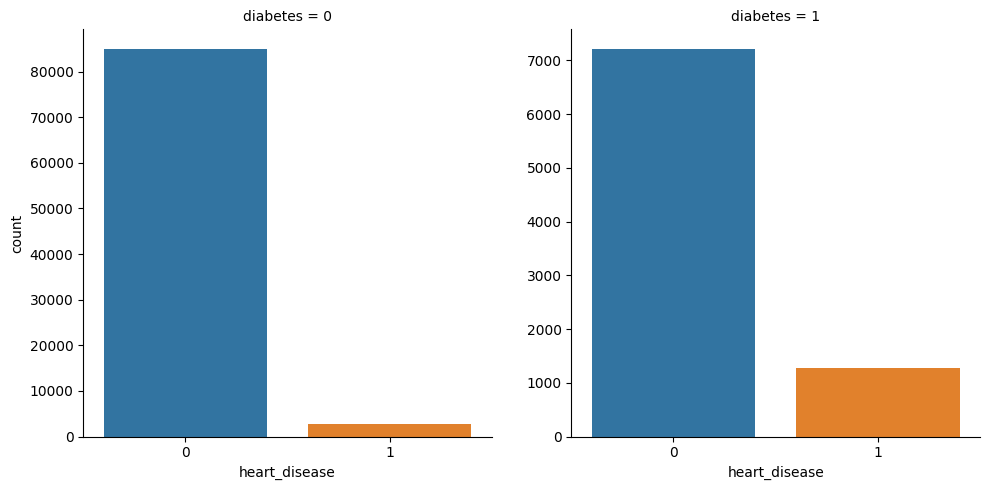

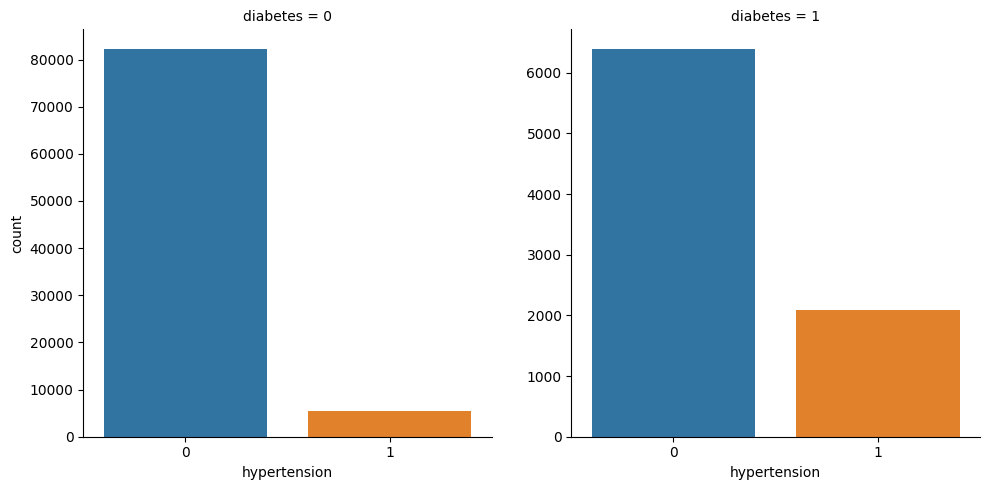

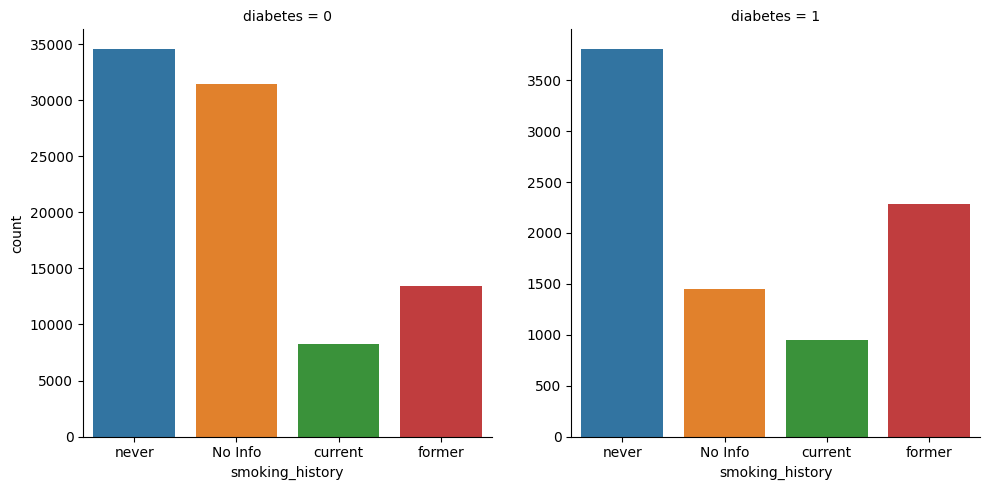

In [21]:
# Categorical plot of all categorical_features as per target values
for feature in categorical_features:
    g = sns.catplot(x=feature, col='diabetes', kind='count', data=df, sharey=False)


In [22]:
# chi2 Test to get the significant association between variables means some categories might directly affect the prediction of diabetes
# while some of it would have no impact at all.
from scipy.stats import chi2_contingency

for col in categorical_features:
    data_crosstab = pd.crosstab(df['diabetes'], df[col],)
    print(data_crosstab,"\n")
    c, p, dof, expected = chi2_contingency(data_crosstab)
    if p<.05:
        result="There is a significant association between these varibles "
    else:
        result="There is no association those varibles"
    print('--> P-value is',p,"\n-->",'chi2 value is',c,"\n-->",result,"\n")

gender    Female   Male  Other
diabetes                      
0          51714  35932     18
1           4447   4035      0 

--> P-value is 5.4063313009771595e-31 
--> chi2 value is 139.3851343057988 
--> There is a significant association between these varibles  

heart_disease      0     1
diabetes                  
0              85008  2656
1               7215  1267 

--> P-value is 0.0 
--> chi2 value is 2798.8652727125022 
--> There is a significant association between these varibles  

hypertension      0     1
diabetes                 
0             82289  5375
1              6396  2086 

--> P-value is 0.0 
--> chi2 value is 3680.0329357951405 
--> There is a significant association between these varibles  

smoking_history  No Info  current  former  never
diabetes                                        
0                  31442     8249   13386  34587
1                   1445      948    2280   3809 

--> P-value is 0.0 
--> chi2 value is 1524.3838903350027 
--> There is a 

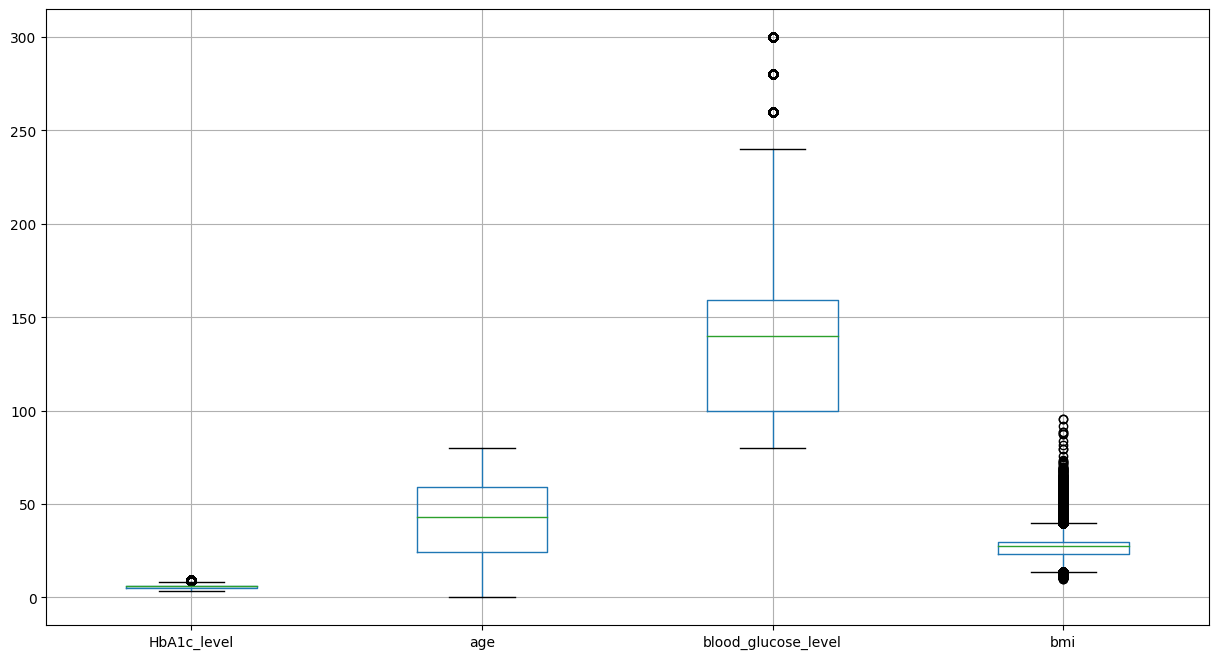

In [23]:
plt.figure(figsize=(15,8))
df.boxplot(column=list(continuous_features))
plt.show()

In [24]:
df1=df.copy()

In [25]:
df1

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,No Info,24.60,4.8,145,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [26]:
categorical_features

['gender', 'heart_disease', 'hypertension', 'smoking_history']

In [27]:
## Write code to convert following columns to equivalent dummy variables

df1 = pd.get_dummies(df,columns=categorical_features,drop_first=True)
# df1 = df1.drop(columns=categorical_features,inplace = True)

In [28]:
df1

,age,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,heart_disease_1,hypertension_1,smoking_history_current,smoking_history_former,smoking_history_never
0,80.0,25.19,6.6,140,0,0,0,1,0,0,0,1
1,54.0,27.32,6.6,80,0,0,0,0,0,0,0,0
2,28.0,27.32,5.7,158,0,1,0,0,0,0,0,1
3,36.0,23.45,5.0,155,0,0,0,0,0,1,0,0
4,76.0,20.14,4.8,155,0,1,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99994,36.0,24.60,4.8,145,0,0,0,0,0,0,0,0
99996,2.0,17.37,6.5,100,0,0,0,0,0,0,0,0
99997,66.0,27.83,5.7,155,0,1,0,0,0,0,1,0
99998,24.0,35.42,4.0,100,0,0,0,0,0,0,0,1


In [29]:
# Spilliting in to x and y
X = df1.drop(columns =['diabetes'])
y = df1['diabetes']

In [30]:
# importing train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

# Standardization

- Let's perform Standardization to transform the data in similar unit

In [31]:
X_train

,age,bmi,HbA1c_level,blood_glucose_level,gender_Male,gender_Other,heart_disease_1,hypertension_1,smoking_history_current,smoking_history_former,smoking_history_never
65477,65.00,27.32,5.8,100,0,0,0,0,0,0,1
3451,62.00,27.32,4.0,100,1,0,0,0,0,1,0
24301,45.00,23.20,6.0,159,0,0,0,0,0,0,1
58033,80.00,23.45,3.5,100,0,0,0,0,0,0,1
51256,0.48,27.32,4.5,145,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
61753,28.00,34.87,4.8,126,1,0,0,0,1,0,0
14216,51.00,19.61,6.6,140,1,0,0,0,1,0,0
53076,53.00,27.32,6.2,80,0,0,0,0,0,1,0
83916,36.00,23.13,6.0,159,0,0,0,0,0,0,1


In [32]:
# We will use Standard Scaler and scale the continuous features
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

cols = list(continuous_features)
X_train[cols] = std_scaler.fit_transform(X_train[cols])

X_train

,age,bmi,HbA1c_level,blood_glucose_level,gender_Male,gender_Other,heart_disease_1,hypertension_1,smoking_history_current,smoking_history_former,smoking_history_never
65477,1.032373,-0.000969,0.253947,-0.933620,0,0,0,0,0,0,1
3451,0.898847,-0.000969,-1.420704,-0.933620,1,0,0,0,0,1,0
24301,0.142194,-0.610953,0.440019,0.510504,0,0,0,0,0,0,1
58033,1.700008,-0.573939,-1.885885,-0.933620,0,0,0,0,0,0,1
51256,-1.839346,-0.000969,-0.955523,0.167830,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
61753,-0.614459,1.116841,-0.676415,-0.297226,1,0,0,0,1,0,0
14216,0.409248,-1.142468,0.998236,0.045447,1,0,0,0,1,0,0
53076,0.498266,-0.000969,0.626091,-1.423153,0,0,0,0,0,1,0
83916,-0.258387,-0.621317,0.440019,0.510504,0,0,0,0,0,0,1


In [33]:

y_train

65477    0
3451     0
24301    0
58033    0
51256    0
        ..
61753    0
14216    0
53076    0
83916    0
38944    0
Name: diabetes, Length: 72109, dtype: int64

In [34]:
X_test[cols] = std_scaler.transform(X_test[cols])

X_test

,age,bmi,HbA1c_level,blood_glucose_level,gender_Male,gender_Other,heart_disease_1,hypertension_1,smoking_history_current,smoking_history_former,smoking_history_never
72942,-0.658968,0.110072,-1.420704,0.534980,1,0,0,0,0,0,0
81149,0.943355,-0.000969,0.160911,0.486027,1,0,0,0,0,1,0
26602,-1.193075,1.464769,-1.885885,0.534980,1,0,0,0,0,0,0
43338,-0.169369,-0.171232,-1.885885,0.486027,0,0,0,0,0,0,0
88990,0.720811,1.173102,-0.490343,-0.933620,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
56660,-1.821542,-1.001817,0.440019,0.534980,1,0,0,0,0,0,0
39753,1.610990,2.490786,2.486815,-0.297226,0,0,0,1,1,0,0
35697,-0.302896,-0.000969,0.905200,0.045447,0,0,0,0,0,0,0
51000,0.631793,1.331520,-1.420704,0.486027,0,0,0,0,0,1,0


In [35]:
y_test

72942    0
81149    0
26602    0
43338    0
88990    0
        ..
56660    0
39753    1
35697    0
51000    0
15584    0
Name: diabetes, Length: 24037, dtype: int64

In [36]:
def plotRocAuc(model, X, y):
    probabilities = model.predict_proba(X)
    probabilities = probabilities[:, 1] # keep probabilities for first class only

    # Compute the ROC curve
    fpr, tpr, thresholds = roc_curve(y, probabilities)

    # Plot the "dumb model" line
    plt.plot([0, 1], [0, 1], linestyle='--')

    # Plot the model line
    plt.plot(fpr, tpr, marker='.')
    plt.text(0.75, 0.25, "AUC: " + str(round(roc_auc_score(y, probabilities),2)))

    # show the plot
    plt.show()

## Logistic Regression

Model accuracy score: 0.9599
Classification report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     21890
           1       0.87      0.65      0.74      2147

    accuracy                           0.96     24037
   macro avg       0.92      0.82      0.86     24037
weighted avg       0.96      0.96      0.96     24037

Confusion Matrix:


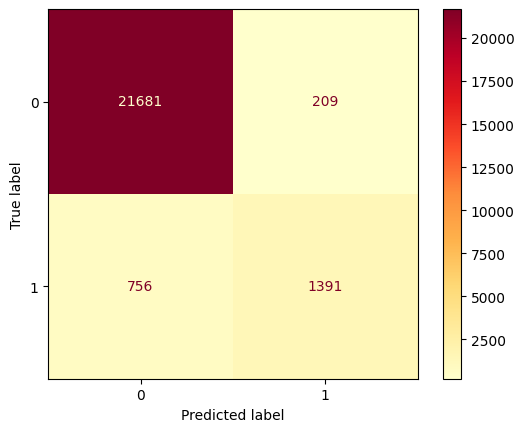

---------------------------------------------------------------------------
ROC curve:


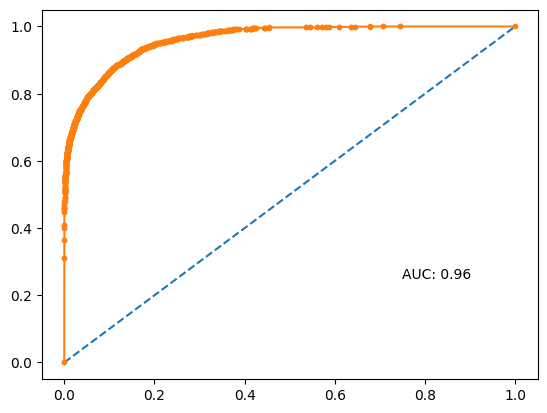

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score


# making model for logistic regression
clf_LR= LogisticRegression(random_state=11).fit(X_train, y_train)
pred = clf_LR.predict(X_test)

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, pred)))
print("Classification report:\n")
print(classification_report(y_test,pred))

print("Confusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap='YlOrRd')
plt.show()
print("---------------------------------------------------------------------------")

print("ROC curve:")
plotRocAuc(clf_LR,X_test,y_test)


## Naive Bayes

Model accuracy score: 0.5987
Classification report:

              precision    recall  f1-score   support

           0       1.00      0.56      0.72     21890
           1       0.18      0.98      0.30      2147

    accuracy                           0.60     24037
   macro avg       0.59      0.77      0.51     24037
weighted avg       0.92      0.60      0.68     24037

Confusion Matrix:


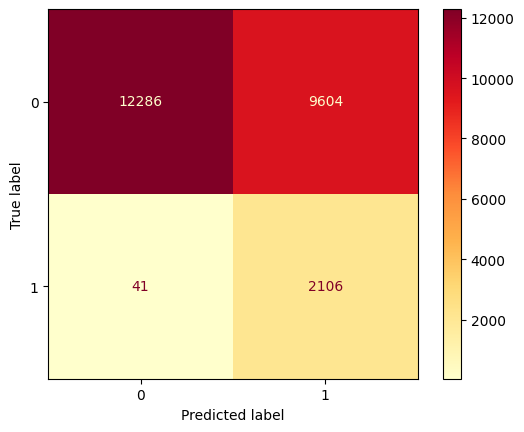

---------------------------------------------------------------------------
ROC curve:


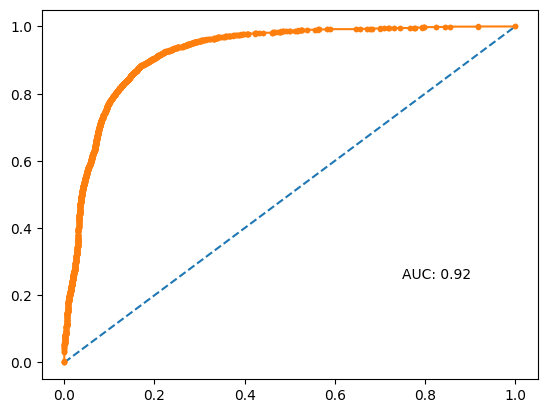

In [38]:
from sklearn.naive_bayes import GaussianNB


clf_gnb = GaussianNB()
pred = clf_gnb.fit(X_train, y_train).predict(X_test)

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, pred)))
print("Classification report:\n")
print(classification_report(y_test,pred))

print("Confusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test,pred, cmap='YlOrRd')
plt.show()
print("---------------------------------------------------------------------------")

print("ROC curve:")
plotRocAuc(clf_gnb,X_test,y_test)


## Decision Tree

Model accuracy score: 0.9595
Classification report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     21890
           1       0.79      0.75      0.77      2147

    accuracy                           0.96     24037
   macro avg       0.88      0.86      0.87     24037
weighted avg       0.96      0.96      0.96     24037

Confusion Matrix:


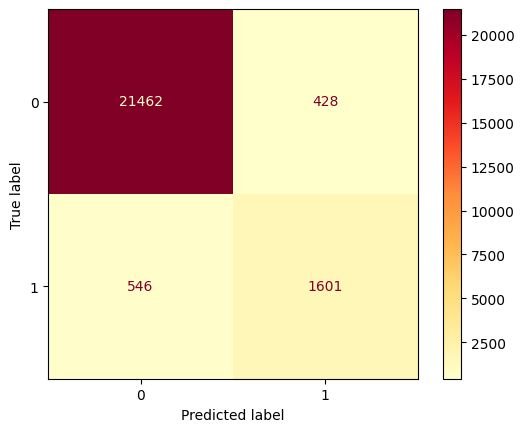

---------------------------------------------------------------------------
ROC curve:


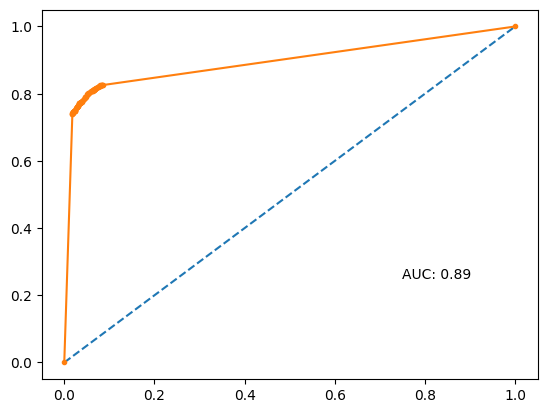

In [39]:
from sklearn.tree import DecisionTreeClassifier


clf_dtc = DecisionTreeClassifier(criterion='gini', max_depth=20, random_state=0)
clf_dtc.fit(X_train, y_train)

pred = clf_dtc.predict(X_test)
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, pred)))
print("Classification report:\n")
print(classification_report(y_test,pred))

print("Confusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap='YlOrRd')
plt.show()
print("---------------------------------------------------------------------------")

print("ROC curve:")
plotRocAuc(clf_dtc,X_test,y_test)


## Random Forest

Model accuracy score: 0.9700
Classification report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     21890
           1       0.94      0.71      0.81      2147

    accuracy                           0.97     24037
   macro avg       0.96      0.85      0.90     24037
weighted avg       0.97      0.97      0.97     24037

Confusion Matrix:


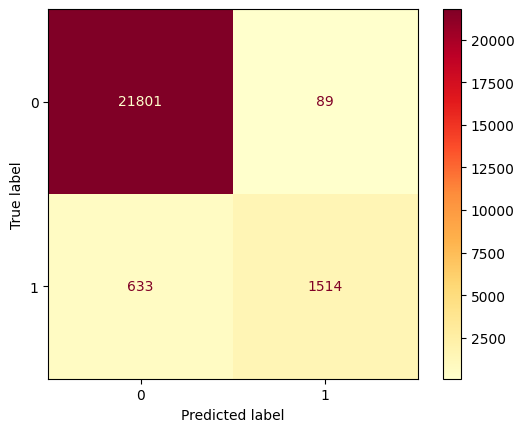

---------------------------------------------------------------------------
ROC curve:


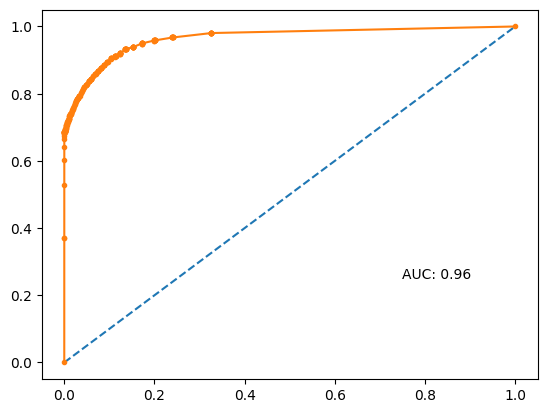

In [40]:
from sklearn.ensemble import  RandomForestClassifier


clf_RF= RandomForestClassifier().fit(X_train, y_train)

pred = clf_RF.predict(X_test)
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, pred)))
print("Classification report:\n")
print(classification_report(y_test,pred))

print("Confusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap='YlOrRd')
plt.show()
print("---------------------------------------------------------------------------")

print("ROC curve:")
plotRocAuc(clf_RF,X_test,y_test)


Model accuracy score: 0.9709
Classification report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     21890
           1       0.96      0.71      0.81      2147

    accuracy                           0.97     24037
   macro avg       0.96      0.85      0.90     24037
weighted avg       0.97      0.97      0.97     24037

Confusion Matrix:


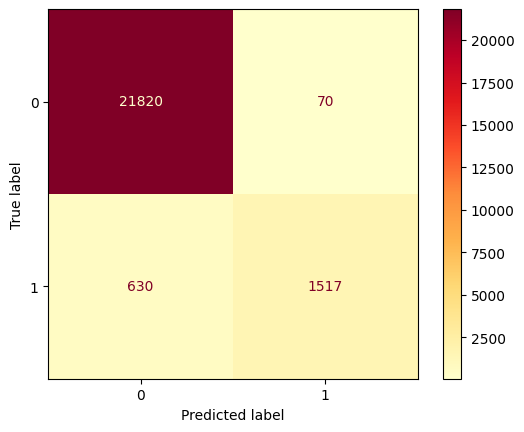

---------------------------------------------------------------------------
ROC curve:


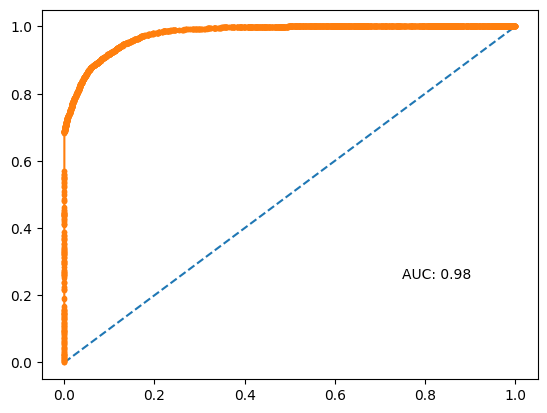

In [41]:
import xgboost as xgb


clf_xgb= xgb.XGBClassifier().fit(X_train, y_train)

pred = clf_xgb.predict(X_test)
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, pred)))
print("Classification report:\n")
print(classification_report(y_test,pred))

print("Confusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap='YlOrRd')
plt.show()
print("---------------------------------------------------------------------------")

print("ROC curve:")
plotRocAuc(clf_xgb,X_test,y_test)


In [42]:
# using SMOTE for oversampling
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN, SMOTETomek

smt = SMOTE(k_neighbors=200, random_state=2)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)

smt_enn = SMOTEENN(random_state=2)
X_train_smt_enn, y_train_smt_enn = smt_enn.fit_resample(X_train, y_train)

smt_tom = SMOTETomek(random_state=2)
X_train_smt_tom, y_train_smt_tom = smt_tom.fit_resample(X_train, y_train)

Model accuracy score: 0.9540
Classification report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.97     21890
           1       0.71      0.82      0.76      2147

    accuracy                           0.95     24037
   macro avg       0.85      0.90      0.87     24037
weighted avg       0.96      0.95      0.96     24037

Confusion Matrix:


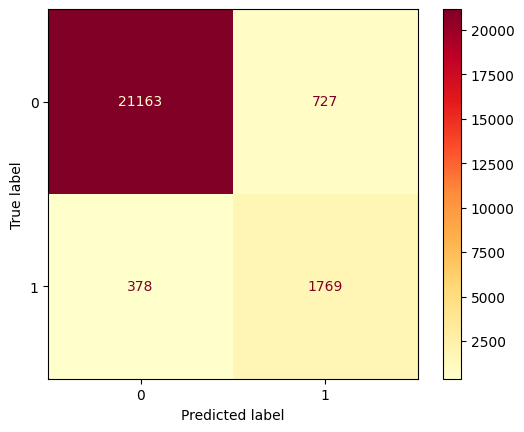

---------------------------------------------------------------------------
ROC curve:


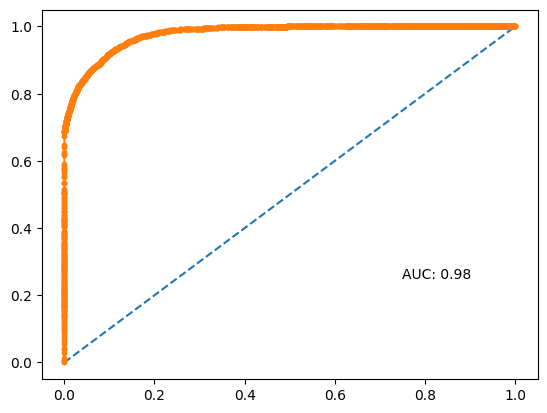

In [43]:
import xgboost as xgb


clf_xgb= xgb.XGBClassifier().fit(X_train_smt_enn, y_train_smt_enn)

pred = clf_xgb.predict(X_test)
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, pred)))
print("Classification report:\n")
print(classification_report(y_test,pred))

print("Confusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap='YlOrRd')
plt.show()
print("---------------------------------------------------------------------------")

print("ROC curve:")
plotRocAuc(clf_xgb,X_test,y_test)


In [44]:
result = pd.DataFrame()

result['Model'] = ['LR', 'NB', 'DT','RF','XGB','XGB_SMOTE']
result['Recall_macro_avg'] = [0.81,0.78, 0.85, 0.83, 0.84, 0.88]


In [45]:
result

,Model,Recall_macro_avg
0,LR,0.81
1,NB,0.78
2,DT,0.85
3,RF,0.83
4,XGB,0.84
5,XGB_SMOTE,0.88
